In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from imblearn.over_sampling import SMOTE

In [ ]:
df_train=pd.read_csv('/content/UNSW_NB15_training-set.csv')
df_test=pd.read_csv('/content/UNSW_NB15_testing-set.csv')

# EDA

In [ ]:

df_train.head()

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,...,1,1,0,0,0,1,1,0,Normal,0
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,...,1,2,0,0,0,1,6,0,Normal,0
2,3,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,...,1,3,0,0,0,2,6,0,Normal,0
3,4,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,...,1,3,1,1,0,2,1,0,Normal,0
4,5,0.449454,tcp,-,FIN,10,6,534,268,33.373826,...,1,40,0,0,0,2,39,0,Normal,0


In [ ]:
df_test.head()

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.0902,...,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.0003,...,1,2,0,0,0,1,2,0,Normal,0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.0051,...,1,3,0,0,0,1,3,0,Normal,0
3,4,0.000006,udp,-,INT,2,0,900,0,166666.6608,...,1,3,0,0,0,2,3,0,Normal,0
4,5,0.000010,udp,-,INT,2,0,2126,0,100000.0025,...,1,3,0,0,0,2,3,0,Normal,0


In [ ]:
df_train.shape , df_test.shape

((175341, 45), (82332, 45))

In [ ]:
df_train.info() ,df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175341 entries, 0 to 175340
Data columns (total 45 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 175341 non-null  int64  
 1   dur                175341 non-null  float64
 2   proto              175341 non-null  object 
 3   service            175341 non-null  object 
 4   state              175341 non-null  object 
 5   spkts              175341 non-null  int64  
 6   dpkts              175341 non-null  int64  
 7   sbytes             175341 non-null  int64  
 8   dbytes             175341 non-null  int64  
 9   rate               175341 non-null  float64
 10  sttl               175341 non-null  int64  
 11  dttl               175341 non-null  int64  
 12  sload              175341 non-null  float64
 13  dload              175341 non-null  float64
 14  sloss              175341 non-null  int64  
 15  dloss              175341 non-null  int64  
 16  si

(None, None)

In [ ]:
df_train.describe()

,id,dur,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,...,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,label
count,175341.000000,175341.000000,175341.000000,175341.000000,1.753410e+05,1.753410e+05,1.753410e+05,175341.000000,175341.000000,1.753410e+05,...,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000
mean,87671.000000,1.359389,20.298664,18.969591,8.844844e+03,1.492892e+04,9.540619e+04,179.546997,79.609567,7.345403e+07,...,5.383538,4.206255,8.729881,0.014948,0.014948,0.133066,6.955789,9.100758,0.015752,0.680622
std,50616.731112,6.480249,136.887597,110.258271,1.747656e+05,1.436542e+05,1.654010e+05,102.940011,110.506863,1.883574e+08,...,8.047104,5.783585,10.956186,0.126048,0.126048,0.701208,8.321493,10.756952,0.124516,0.466237
min,1.000000,0.000000,1.000000,0.000000,2.800000e+01,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00,...,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000
25%,43836.000000,0.000008,2.000000,0.000000,1.140000e+02,0.000000e+00,3.278614e+01,62.000000,0.000000,1.305334e+04,...,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,2.000000,2.000000,0.000000,0.000000
50%,87671.000000,0.001582,2.000000,2.000000,4.300000e+02,1.640000e+02,3.225807e+03,254.000000,29.000000,8.796748e+05,...,1.000000,1.000000,3.000000,0.000000,0.000000,0.000000,3.000000,4.000000,0.000000,1.000000
75%,131506.000000,0.668069,12.000000,10.000000,1.418000e+03,1.102000e+03,1.250000e+05,254.000000,252.000000,8.888889e+07,...,5.000000,3.000000,12.000000,0.000000,0.000000,0.000000,9.000000,12.000000,0.000000,1.000000
max,175341.000000,59.999989,9616.000000,10974.000000,1.296523e+07,1.465555e+07,1.000000e+06,255.000000,254.000000,5.988000e+09,...,51.000000,46.000000,65.000000,4.000000,4.000000,30.000000,60.000000,62.000000,1.000000,1.000000


In [ ]:
df_train.dtypes

,0
id,int64
dur,float64
proto,object
service,object
state,object
spkts,int64
dpkts,int64
sbytes,int64
dbytes,int64
rate,float64


In [ ]:
df_test.dtypes

,0
id,int64
dur,float64
proto,object
service,object
state,object
spkts,int64
dpkts,int64
sbytes,int64
dbytes,int64
rate,float64


In [ ]:
df_train.isnull().sum()

,0
id,0
dur,0
proto,0
service,0
state,0
spkts,0
dpkts,0
sbytes,0
dbytes,0
rate,0


In [ ]:
df_test.isnull().sum()

,0
id,0
dur,0
proto,0
service,0
state,0
spkts,0
dpkts,0
sbytes,0
dbytes,0
rate,0


In [ ]:
print(df_train.duplicated().sum()) , print(df_test.duplicated().sum())

0
0


(None, None)

In [ ]:
print("Training Data ('label' column):\n")
print(df_train['label'].value_counts())

print("\nTraining Data ('attack_cat' column):\n")
print(df_train['attack_cat'].value_counts())

print("\nTesting Data ('label' column):\n")
print(df_test['label'].value_counts())

print("\nTesting Data ('attack_cat' column):\n")
print(df_test['attack_cat'].value_counts())

Training Data ('label' column):

label
1    119341
0     56000
Name: count, dtype: int64

Training Data ('attack_cat' column):

attack_cat
Normal            56000
Generic           40000
Exploits          33393
Fuzzers           18184
DoS               12264
Reconnaissance    10491
Analysis           2000
Backdoor           1746
Shellcode          1133
Worms               130
Name: count, dtype: int64

Testing Data ('label' column):

label
1    45332
0    37000
Name: count, dtype: int64

Testing Data ('attack_cat' column):

attack_cat
Normal            37000
Generic           18871
Exploits          11132
Fuzzers            6062
DoS                4089
Reconnaissance     3496
Analysis            677
Backdoor            583
Shellcode           378
Worms                44
Name: count, dtype: int64


Class distribution (normal vs attack) in Training Data:


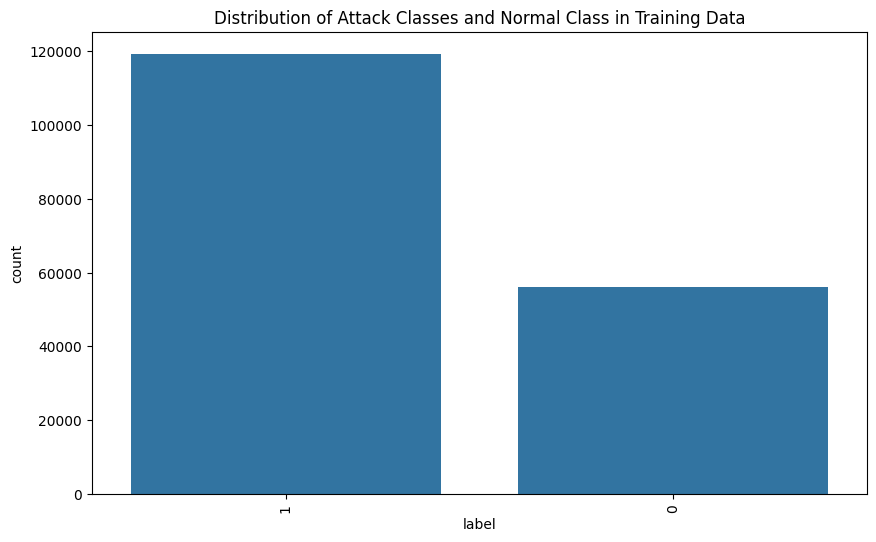

In [ ]:
if 'label' in df_train.columns:
    print("Class distribution (normal vs attack) in Training Data:")

    import matplotlib.pyplot as plt
    import seaborn as sns

    plt.figure(figsize=(10, 6))
    sns.countplot(data=df_train, x='label', order=df_train['label'].value_counts().index)
    plt.xticks(rotation=90)
    plt.title('Distribution of Attack Classes and Normal Class in Training Data')
    plt.show()


Attack Type Distribution in Training Data:


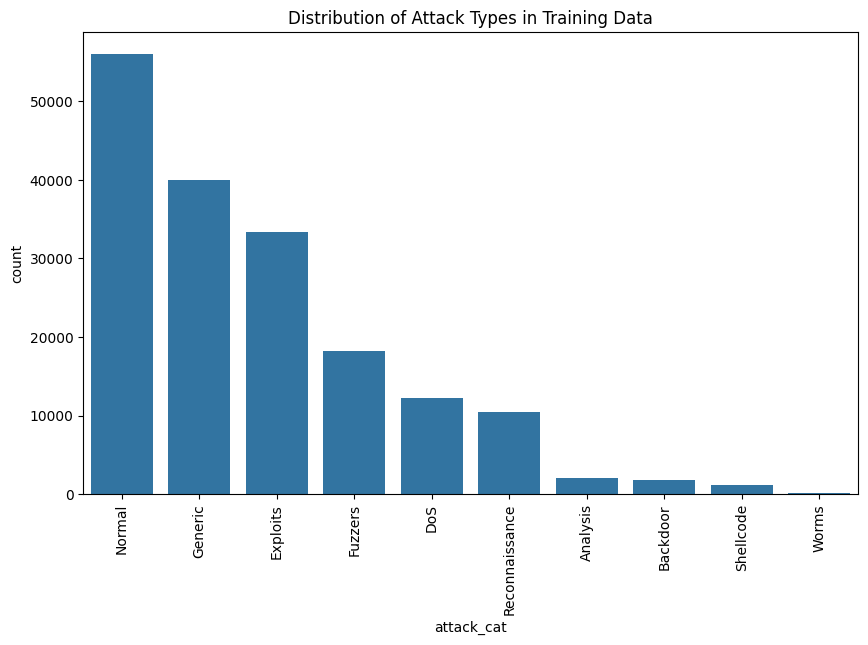

In [ ]:
if 'attack_cat' in df_train.columns:
    print("\nAttack Type Distribution in Training Data:")

    # Plot attack type distribution
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df_train, x='attack_cat', order=df_train['attack_cat'].value_counts().index)
    plt.xticks(rotation=90)
    plt.title('Distribution of Attack Types in Training Data')
    plt.show()


Protocol Distribution in Training Data:
proto
tcp       79946
udp       63283
unas      12084
arp        2859
ospf       2595
          ...  
argus        98
netblt       98
igmp         18
icmp         15
rtp           1
Name: count, Length: 133, dtype: int64


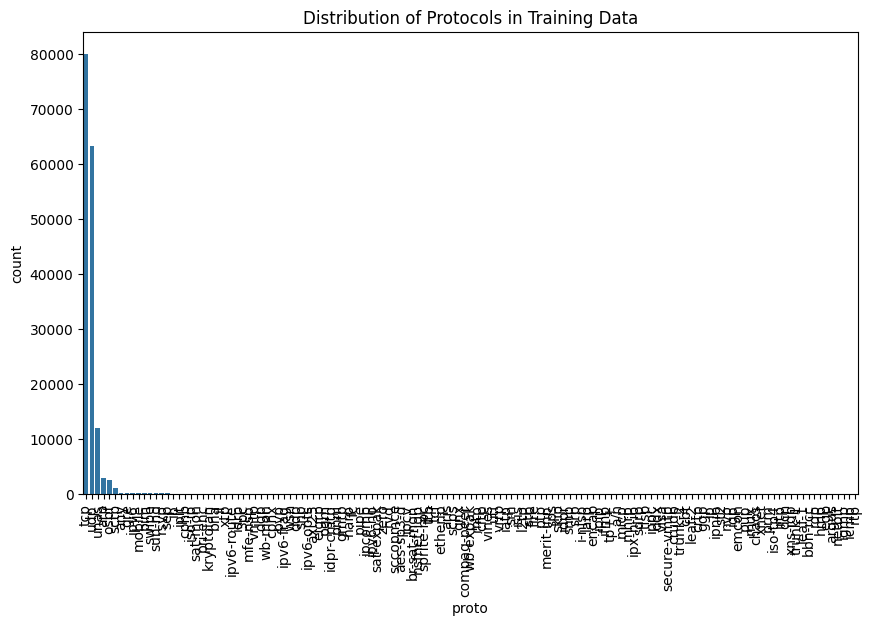


Service Distribution in Training Data:
service
-           94168
dns         47294
http        18724
smtp         5058
ftp-data     3995
ftp          3428
ssh          1302
pop3         1105
dhcp           94
snmp           80
ssl            56
irc            25
radius         12
Name: count, dtype: int64


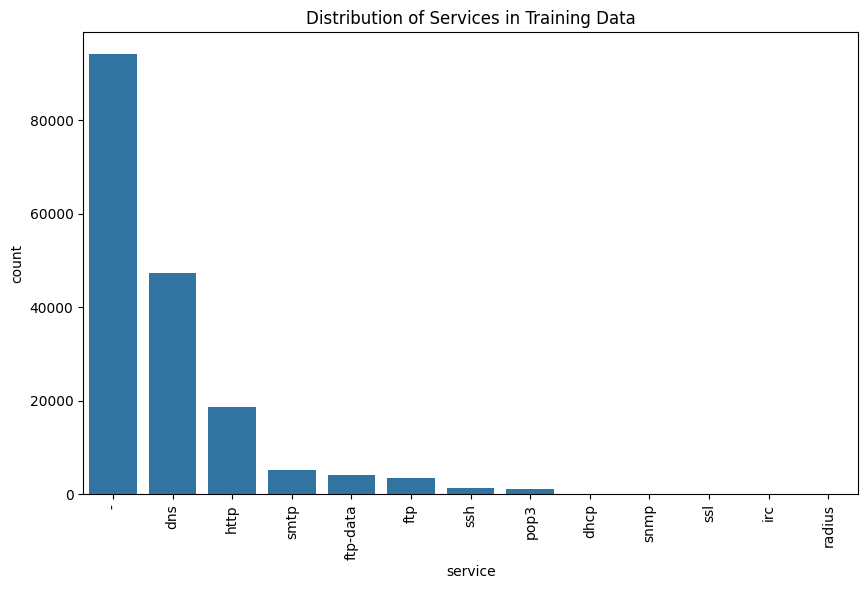

In [ ]:
if 'proto' in df_train.columns:
    print("\nProtocol Distribution in Training Data:")
    print(df_train['proto'].value_counts())

    # Plot protocol distribution
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df_train, x='proto', order=df_train['proto'].value_counts().index)
    plt.xticks(rotation=90)
    plt.title('Distribution of Protocols in Training Data')
    plt.show()

# Examine service distribution (if available)
if 'service' in df_train.columns:
    print("\nService Distribution in Training Data:")
    print(df_train['service'].value_counts())

    # Plot service distribution
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df_train, x='service', order=df_train['service'].value_counts().index)
    plt.xticks(rotation=90)
    plt.title('Distribution of Services in Training Data')
    plt.show()

Highly Correlated Features:
           Feature 1         Feature 2  Correlation
0             sbytes             spkts     0.963791
1             dbytes             dpkts     0.971907
2              sloss             spkts     0.971069
3              sloss            sbytes     0.996109
4              dloss             dpkts     0.978636
5              dloss            dbytes     0.996504
6               dwin              swin     0.990140
7             synack            tcprtt     0.949468
8             ackdat            tcprtt     0.941760
9   ct_src_dport_ltm        ct_dst_ltm     0.962052
10  ct_dst_sport_ltm  ct_src_dport_ltm     0.906793
11    ct_dst_src_ltm        ct_srv_src     0.967138
12        ct_ftp_cmd      is_ftp_login     1.000000
13        ct_srv_dst        ct_srv_src     0.980323
14        ct_srv_dst    ct_dst_src_ltm     0.972370
15   is_sm_ips_ports            sinpkt     0.941319


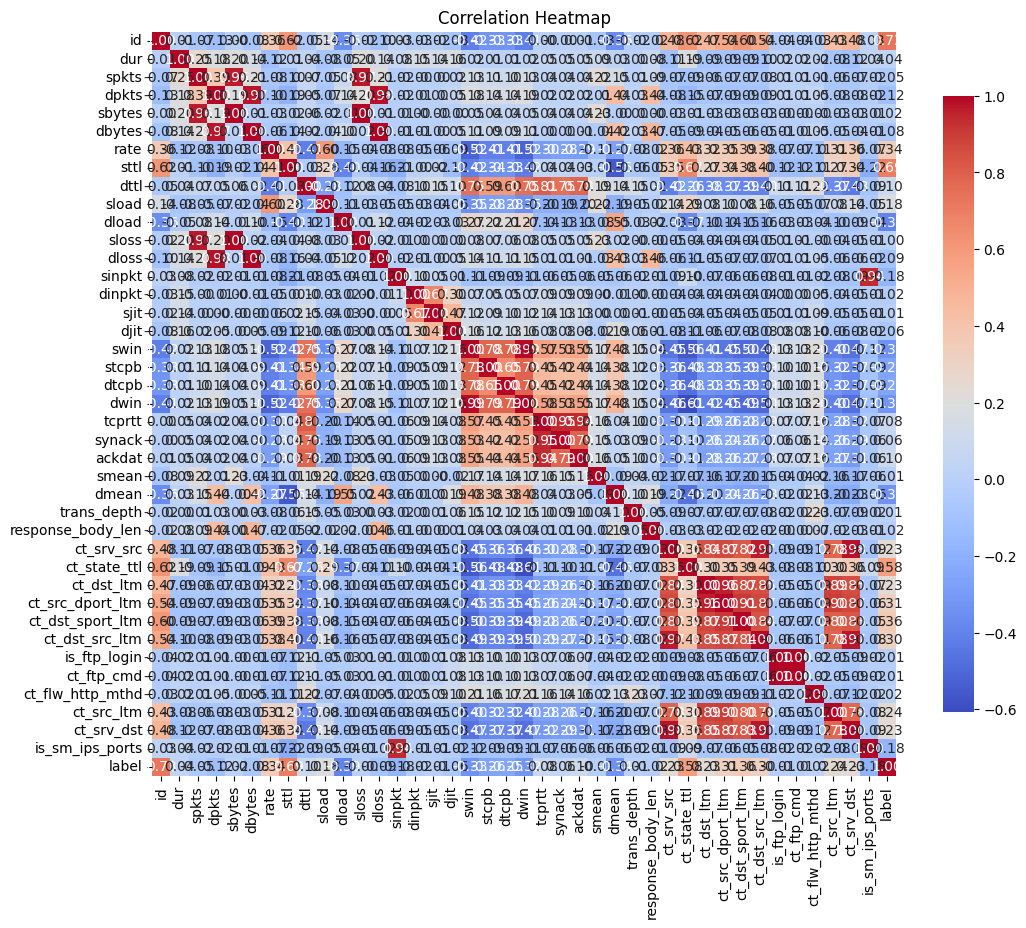

In [ ]:
# Step 1: Select only numeric columns
numeric_columns = df_train.select_dtypes(include=[np.number]).columns
numeric_data = df_train[numeric_columns]

# Step 2: Compute the correlation matrix
corr_matrix = numeric_data.corr()

# Step 3: Identify highly correlated features
threshold = 0.9
high_corr_pairs = []

# Loop through the correlation matrix to find highly correlated pairs
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > threshold:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))

# Convert to DataFrame for better visualization
high_corr_df = pd.DataFrame(high_corr_pairs, columns=['Feature 1', 'Feature 2', 'Correlation'])

# Print highly correlated features
print("Highly Correlated Features:")
print(high_corr_df)

# Step 4: Visualize the Correlation Matrix
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True, cbar_kws={"shrink": .8})
plt.title('Correlation Heatmap')
plt.show()

# Preprocessing

In [ ]:

for col in ['proto', 'service', 'state', 'attack_cat']:
    df_train[col] = df_train[col].astype(str).str.strip()
    df_test[col] = df_test[col].astype(str).str.strip()


In [ ]:
unseen_labels = set(df_test['attack_cat']) - set(df_train['attack_cat'])
print("Unseen labels:", unseen_labels)

Unseen labels: set()


In [ ]:
print("Train attack_cat unique labels:", df_train['attack_cat'].unique())
print("\nTest attack_cat unique labels:", df_test['attack_cat'].unique())


Train attack_cat unique labels: ['Normal' 'Backdoor' 'Analysis' 'Fuzzers' 'Shellcode' 'Reconnaissance'
 'Exploits' 'DoS' 'Worms' 'Generic']

Test attack_cat unique labels: ['Normal' 'Reconnaissance' 'Backdoor' 'DoS' 'Exploits' 'Analysis'
 'Fuzzers' 'Worms' 'Shellcode' 'Generic']


In [ ]:
print("Train proto unique labels:", df_train['proto'].unique())
print("\nTest proto unique labels:", df_test['proto'].unique())

Train proto unique labels: ['tcp' 'udp' 'arp' 'ospf' 'icmp' 'igmp' 'rtp' 'ddp' 'ipv6-frag' 'cftp'
 'wsn' 'pvp' 'wb-expak' 'mtp' 'pri-enc' 'sat-mon' 'cphb' 'sun-nd' 'iso-ip'
 'xtp' 'il' 'unas' 'mfe-nsp' '3pc' 'ipv6-route' 'idrp' 'bna' 'swipe'
 'kryptolan' 'cpnx' 'rsvp' 'wb-mon' 'vmtp' 'ib' 'dgp' 'eigrp' 'ax.25'
 'gmtp' 'pnni' 'sep' 'pgm' 'idpr-cmtp' 'zero' 'rvd' 'mobile' 'narp' 'fc'
 'pipe' 'ipcomp' 'ipv6-no' 'sat-expak' 'ipv6-opts' 'snp' 'ipcv'
 'br-sat-mon' 'ttp' 'tcf' 'nsfnet-igp' 'sprite-rpc' 'aes-sp3-d' 'sccopmce'
 'sctp' 'qnx' 'scps' 'etherip' 'aris' 'pim' 'compaq-peer' 'vrrp' 'iatp'
 'stp' 'l2tp' 'srp' 'sm' 'isis' 'smp' 'fire' 'ptp' 'crtp' 'sps'
 'merit-inp' 'idpr' 'skip' 'any' 'larp' 'ipip' 'micp' 'encap' 'ifmp'
 'tp++' 'a/n' 'ipv6' 'i-nlsp' 'ipx-n-ip' 'sdrp' 'tlsp' 'gre' 'mhrp' 'ddx'
 'ippc' 'visa' 'secure-vmtp' 'uti' 'vines' 'crudp' 'iplt' 'ggp' 'ip'
 'ipnip' 'st2' 'argus' 'bbn-rcc' 'egp' 'emcon' 'igp' 'nvp' 'pup' 'xnet'
 'chaos' 'mux' 'dcn' 'hmp' 'prm' 'trunk-1' 'xns-idp' 'le

In [ ]:
print("Train state unique labels:", df_train['state'].unique())
print("\nTest state unique labels:", df_test['state'].unique())

Train state unique labels: ['FIN' 'INT' 'CON' 'ECO' 'REQ' 'RST' 'PAR' 'URN' 'no']

Test state unique labels: ['INT' 'FIN' 'REQ' 'ACC' 'CON' 'RST' 'CLO']


In [ ]:
print("Train service unique labels:", df_train['service'].unique())
print("\nTest service unique labels:", df_test['service'].unique())

Train service unique labels: ['-' 'ftp' 'smtp' 'snmp' 'http' 'ftp-data' 'dns' 'ssh' 'radius' 'pop3'
 'dhcp' 'ssl' 'irc']

Test service unique labels: ['-' 'http' 'ftp' 'ftp-data' 'smtp' 'pop3' 'dns' 'snmp' 'ssl' 'dhcp' 'irc'
 'radius' 'ssh']


In [ ]:
le = LabelEncoder()
df_train['proto']=le.fit_transform(df_train['proto'])
df_train['service']=le.fit_transform(df_train['service'])
df_train['state']=le.fit_transform(df_train['state'])

df_test['proto']=le.fit_transform(df_test['proto'])
df_test['service']=le.fit_transform(df_test['service'])
df_test['state']=le.fit_transform(df_test['state'])

le_attack = LabelEncoder()
df_train['attack_cat_encoded'] = le_attack.fit_transform(df_train['attack_cat'])
df_test['attack_cat_encoded'] = le_attack.transform(df_test['attack_cat'])

In [ ]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175341 entries, 0 to 175340
Data columns (total 46 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id                  175341 non-null  int64  
 1   dur                 175341 non-null  float64
 2   proto               175341 non-null  int64  
 3   service             175341 non-null  int64  
 4   state               175341 non-null  int64  
 5   spkts               175341 non-null  int64  
 6   dpkts               175341 non-null  int64  
 7   sbytes              175341 non-null  int64  
 8   dbytes              175341 non-null  int64  
 9   rate                175341 non-null  float64
 10  sttl                175341 non-null  int64  
 11  dttl                175341 non-null  int64  
 12  sload               175341 non-null  float64
 13  dload               175341 non-null  float64
 14  sloss               175341 non-null  int64  
 15  dloss               175341 non-nul

In [ ]:
df_train_processed = df_train.drop(['id','attack_cat'], axis=1)
df_test_processed = df_test.drop(['id','attack_cat'], axis=1)

# Binary Classification (label)

In [ ]:
# Split into features and target
X = df_train_processed.drop(['label', 'attack_cat_encoded'], axis=1)
y_binary = df_train_processed['label']

# Split into train and validation (80-20 split)
X_train, X_val, y_train_binary, y_val_binary = train_test_split(X, y_binary, test_size=0.2, random_state=42, stratify=y_binary)

# Handle class imbalance using SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train_binary)

# Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_smote)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(df_test_processed.drop(['label', 'attack_cat_encoded'], axis=1))

In [ ]:
from typing import Counter
print("Before SMOTE:", Counter(y_train_binary))
print("After SMOTE:", Counter(y_train_smote))


Before SMOTE: Counter({1: 95472, 0: 44800})
After SMOTE: Counter({1: 95472, 0: 95472})


# Binary Classification Model

In [ ]:
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)
rf.fit(X_train_scaled, y_train_smote)

y_val_pred_rf = rf.predict(X_val_scaled)
print("Random Forest Validation Report:\n", classification_report(y_val_binary, y_val_pred_rf))

y_test_pred_rf = rf.predict(X_test_scaled)
print("Test Report:\n", classification_report(df_test['label'], y_test_pred_rf))

Random Forest Validation Report:
               precision    recall  f1-score   support

           0       0.93      0.94      0.93     11200
           1       0.97      0.96      0.97     23869

    accuracy                           0.96     35069
   macro avg       0.95      0.95      0.95     35069
weighted avg       0.96      0.96      0.96     35069

Test Report:
               precision    recall  f1-score   support

           0       0.96      0.79      0.87     37000
           1       0.85      0.97      0.91     45332

    accuracy                           0.89     82332
   macro avg       0.90      0.88      0.89     82332
weighted avg       0.90      0.89      0.89     82332



In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=5,
    random_state=42,
    eval_metric='logloss'
)
xgb.fit(X_train_scaled, y_train_smote)

y_val_pred_xgb = xgb.predict(X_val_scaled)
print("XGBoost Validation Report:\n", classification_report(y_val_binary, y_val_pred_xgb))

y_test_pred_xgb = xgb.predict(X_test_scaled)
print("Test Report:\n", classification_report(df_test['label'], y_test_pred_xgb))

XGBoost Validation Report:
               precision    recall  f1-score   support

           0       1.00      0.82      0.90     11200
           1       0.92      1.00      0.96     23869

    accuracy                           0.94     35069
   macro avg       0.96      0.91      0.93     35069
weighted avg       0.94      0.94      0.94     35069

Test Report:
               precision    recall  f1-score   support

           0       0.99      0.58      0.74     37000
           1       0.75      1.00      0.85     45332

    accuracy                           0.81     82332
   macro avg       0.87      0.79      0.79     82332
weighted avg       0.86      0.81      0.80     82332



In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)
lr.fit(X_train_scaled, y_train_smote)

y_val_pred_lr = lr.predict(X_val_scaled)
print("Logistic Regression Validation Report:\n", classification_report(y_val_binary, y_val_pred_lr))

y_test_pred_lr = lr.predict(X_test_scaled)
print("Test Report:\n", classification_report(df_test['label'], y_test_pred_lr))

Logistic Regression Validation Report:
               precision    recall  f1-score   support

           0       0.90      0.87      0.88     11200
           1       0.94      0.95      0.95     23869

    accuracy                           0.93     35069
   macro avg       0.92      0.91      0.91     35069
weighted avg       0.93      0.93      0.93     35069

Test Report:
               precision    recall  f1-score   support

           0       0.98      0.54      0.69     37000
           1       0.72      0.99      0.84     45332

    accuracy                           0.79     82332
   macro avg       0.85      0.76      0.77     82332
weighted avg       0.84      0.79      0.77     82332



In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import pandas as pd

results = {}


models = {
    'Random Forest': rf,
    'XGBoost': xgb,
    'Logistic Regression': lr,
    #'SVM': svm
}


for name, model in models.items():
    y_pred = model.predict(X_test_scaled)

    results[name] = {
        'Precision': precision_score(df_test['label'], y_pred),
        'Recall': recall_score(df_test['label'], y_pred),
        'F1-Score': f1_score(df_test['label'], y_pred),
        'Accuracy': accuracy_score(df_test['label'], y_pred)
    }


comparison_df = pd.DataFrame(results).T
print(comparison_df)

                     Precision    Recall  F1-Score  Accuracy
Random Forest         0.849537  0.971499  0.906434  0.889569
XGBoost               0.745829  0.997044  0.853332  0.811288
Logistic Regression   0.723700  0.992301  0.836979  0.787167


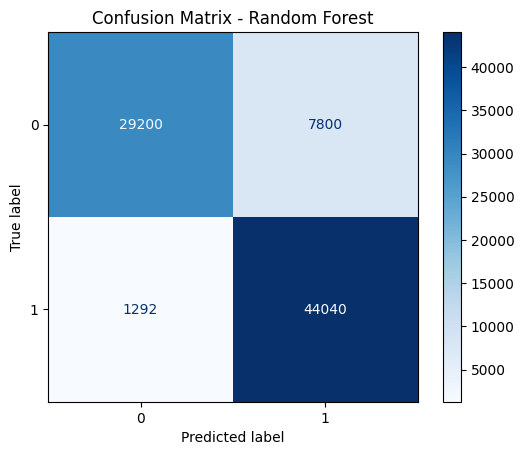

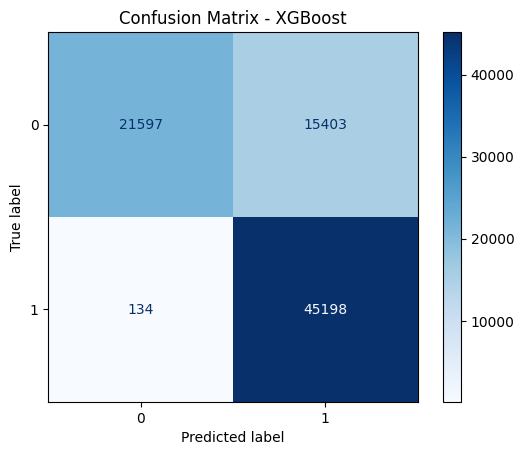

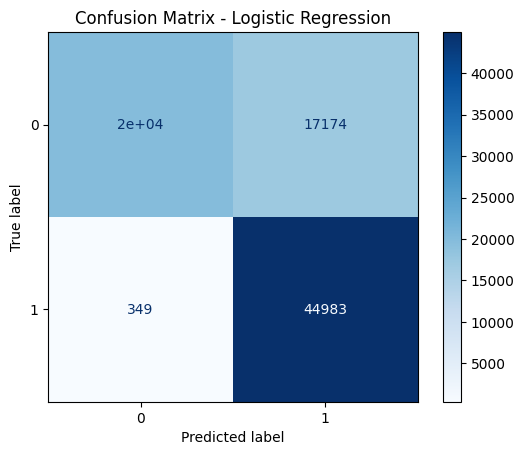

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# قائمة النماذج
models = {
    'Random Forest': rf,
    'XGBoost': xgb,
    'Logistic Regression': lr,
    #'SVM': svm
}

# رسم Confusion Matrix لكل نموذج
for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(df_test['label'], y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues')
    plt.title(f'Confusion Matrix - {name}')
    plt.show()

<Figure size 1000x800 with 0 Axes>

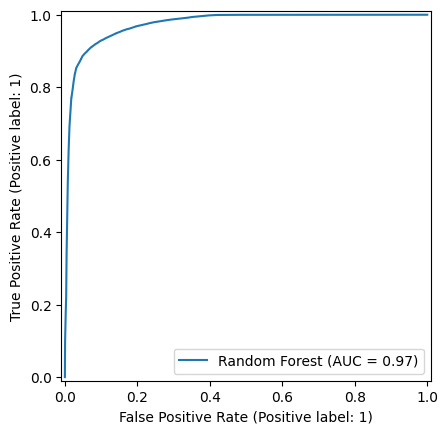

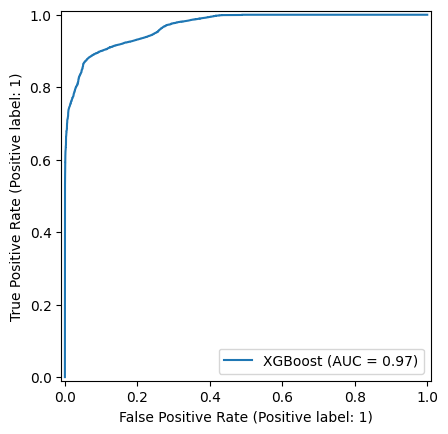

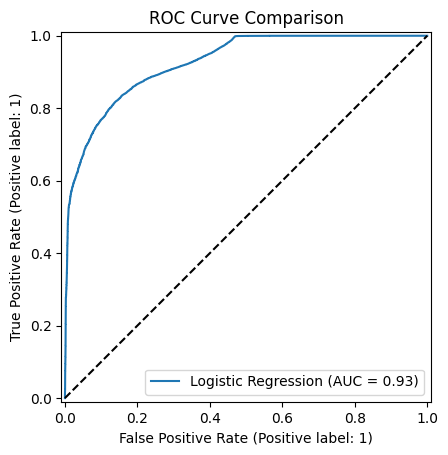

In [ ]:
from sklearn.metrics import RocCurveDisplay

# رسم ROC Curve لكل نموذج
plt.figure(figsize=(10, 8))
for name, model in models.items():
    RocCurveDisplay.from_estimator(model, X_test_scaled, df_test['label'], name=name)
plt.title('ROC Curve Comparison')
plt.plot([0, 1], [0, 1], 'k--')  # خط القاعدة
plt.show()

# Multi-class Classification (attack_cat)

In [ ]:
# For multi-class, we'll only use attack samples (label == 1)
attack_samples = df_train_processed[df_train_processed['label'] == 1]
X_multi = attack_samples.drop(['label', 'attack_cat_encoded'], axis=1)
y_multi = attack_samples['attack_cat_encoded']

# Split into train and validation
X_train_multi, X_val_multi, y_train_multi, y_val_multi = train_test_split(X_multi, y_multi, test_size=0.2, random_state=42, stratify=y_multi)

# Handle class imbalance for multi-class
smote_multi = SMOTE(random_state=42)
X_train_multi_smote, y_train_multi_smote = smote_multi.fit_resample(X_train_multi, y_train_multi)

# Scale the data (using same scaler from binary)
X_train_multi_scaled = scaler.transform(X_train_multi_smote)
X_val_multi_scaled = scaler.transform(X_val_multi)

In [ ]:
df_train['attack_cat_encoded'].value_counts()


,count
attack_cat_encoded,
6,56000
5,40000
3,33393
4,18184
2,12264
7,10491
0,2000
1,1746
8,1133


# Multi-class Classification Model

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

le = LabelEncoder()
y_train_multi_encoded = le.fit_transform(y_train_multi_smote)
y_val_multi_encoded = le.transform(y_val_multi)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Logistic Regression Results:
Accuracy: 0.6144

Classification Report:
              precision    recall  f1-score   support

           0       0.13      0.27      0.18       400
           1       0.05      0.42      0.09       349
           2       0.33      0.24      0.28      2453
           3       0.86      0.38      0.53      6679
           4       0.83      0.68      0.75      3637
           5       1.00      0.97      0.98      8000
           6       0.46      0.38      0.42      2098
           7       0.11      0.81      0.19       227
           8       0.02      0.81      0.04        26

    accuracy                           0.61     23869
   macro avg       0.42      0.55      0.38     23869
weighted avg       0.78      0.61      0.66     23869



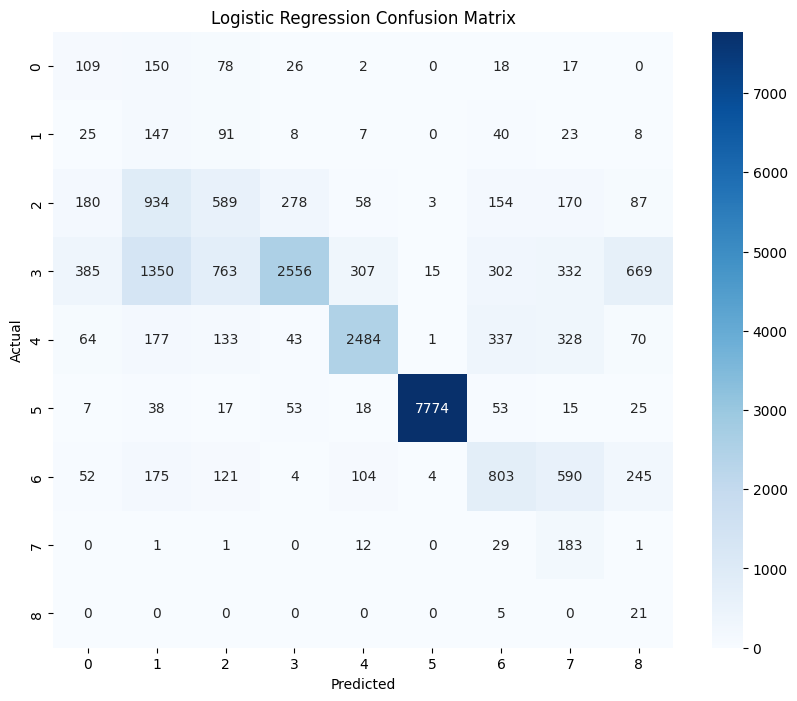

In [ ]:
# 1. Initialize the model
lr_model = LogisticRegression(multi_class='multinomial',
                             solver='lbfgs',
                             max_iter=1000,
                             random_state=42)

# 2. Train the model
lr_model.fit(X_train_multi_scaled, y_train_multi_encoded)

# 3. Predict
y_pred_lr = lr_model.predict(X_val_multi_scaled)

# 4. Evaluate
print("Logistic Regression Results:")
print(f"Accuracy: {accuracy_score(y_val_multi_encoded, y_pred_lr):.4f}")
print("\nClassification Report:")
print(classification_report(y_val_multi_encoded, y_pred_lr))

# 5. Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_val_multi_encoded, y_pred_lr),
            annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


Random Forest Results:
Accuracy: 0.7683

Classification Report:
              precision    recall  f1-score   support

           0       0.17      0.30      0.21       400
           1       0.09      0.16      0.12       349
           2       0.32      0.54      0.40      2453
           3       0.79      0.59      0.68      6679
           4       0.96      0.89      0.92      3637
           5       1.00      0.98      0.99      8000
           6       0.88      0.77      0.82      2098
           7       0.57      0.88      0.69       227
           8       0.37      0.62      0.46        26

    accuracy                           0.77     23869
   macro avg       0.57      0.64      0.59     23869
weighted avg       0.82      0.77      0.79     23869



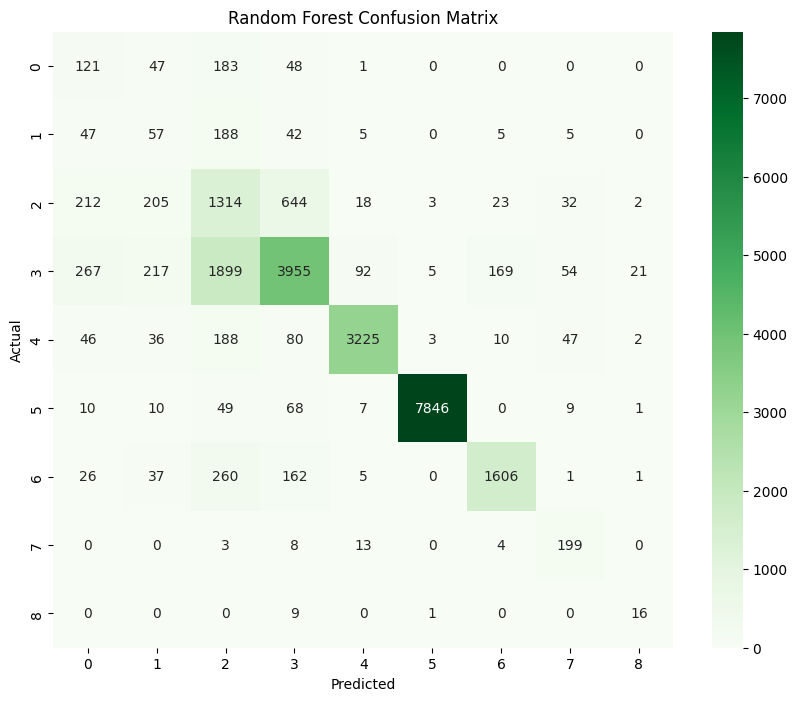

In [ ]:
# 1. Initialize the model
rf_model = RandomForestClassifier(random_state=42)

# 2. Train the model
rf_model.fit(X_train_multi_scaled, y_train_multi_encoded)

# 3. Predict
y_pred_rf = rf_model.predict(X_val_multi_scaled)

# 4. Evaluate
print("\nRandom Forest Results:")
print(f"Accuracy: {accuracy_score(y_val_multi_encoded, y_pred_rf):.4f}")
print("\nClassification Report:")
print(classification_report(y_val_multi_encoded, y_pred_rf))

# 5. Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_val_multi_encoded, y_pred_rf),
            annot=True, fmt='d', cmap='Greens')
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [07:55:39] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBoost Results:
Accuracy: 0.7450

Classification Report:
              precision    recall  f1-score   support

           0       0.12      0.38      0.18       400
           1       0.06      0.31      0.10       349
           2       0.33      0.41      0.37      2453
           3       0.86      0.54      0.66      6679
           4       0.96      0.89      0.92      3637
           5       1.00      0.98      0.99      8000
           6       0.89      0.77      0.83      2098
           7       0.56      0.92      0.69       227
           8       0.22      0.77      0.35        26

    accuracy                           0.75     23869
   macro avg       0.56      0.66      0.56     23869
weighted avg       0.84      0.75      0.78     23869



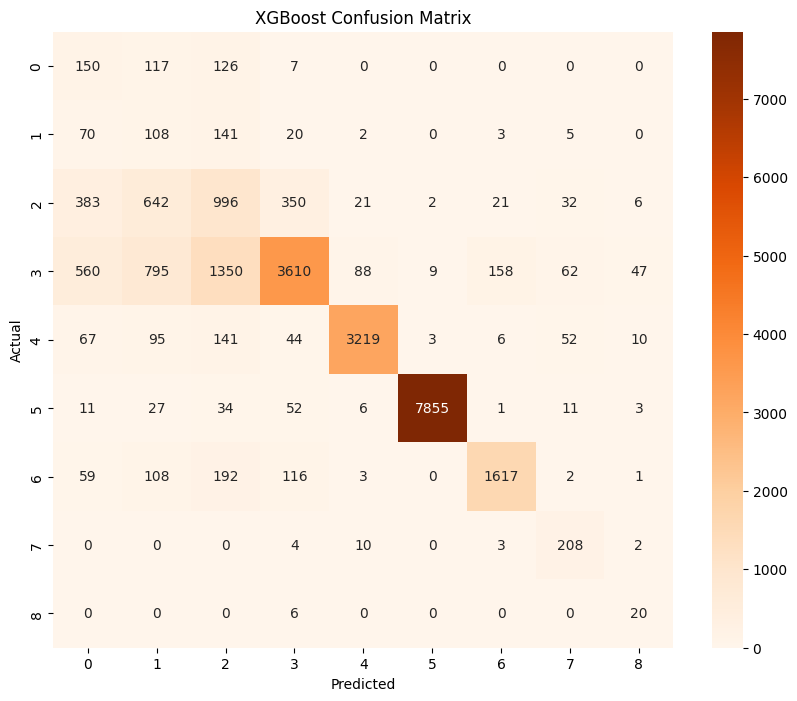

In [ ]:
# 1. Initialize the model
xgb_model = XGBClassifier(random_state=42,
                         eval_metric='mlogloss',
                         use_label_encoder=False)

# 2. Train the model
xgb_model.fit(X_train_multi_scaled, y_train_multi_encoded)

# 3. Predict
y_pred_xgb = xgb_model.predict(X_val_multi_scaled)

# 4. Evaluate
print("\nXGBoost Results:")
print(f"Accuracy: {accuracy_score(y_val_multi_encoded, y_pred_xgb):.4f}")
print("\nClassification Report:")
print(classification_report(y_val_multi_encoded, y_pred_xgb))

# 5. Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_val_multi_encoded, y_pred_xgb),
            annot=True, fmt='d', cmap='Oranges')
plt.title('XGBoost Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()